# Data Selection

The data selected for this project comes from kaggle, created by Sarvesh Chhetri and available in the following link:
https://www.kaggle.com/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset?resource=download


This dataset captures a simulation of 8,000 university students with a wide variety of academic, behavioral and socioeconomic attributes.

The dataset has two versions: The one that classifies the target variable *grade* in a range from A-C, and the second one that has a numeric float value in the *grade* column.

This project will use the one that has the A-C classification (student_performance_grade.csv). So the model will be a classifier.


# Data Preprocessing

Data is preprocessed the following way:
- First, check for missing values
- Checking the distribution of the target variable is important to understand class balance
- Removal of information not important for the model (Student ID column)
- Encoding of the *grade* column so that string values can be transformed into their own, int classes
- Split the train and test sets with an 80/20 distribution
- Detect numeric and categorical columns
- One Hot Encoding for categorical columns
- Normalize numeric variables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np



Missing values:
Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Grade                         0
dtype: int64

Grade distribution:
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64


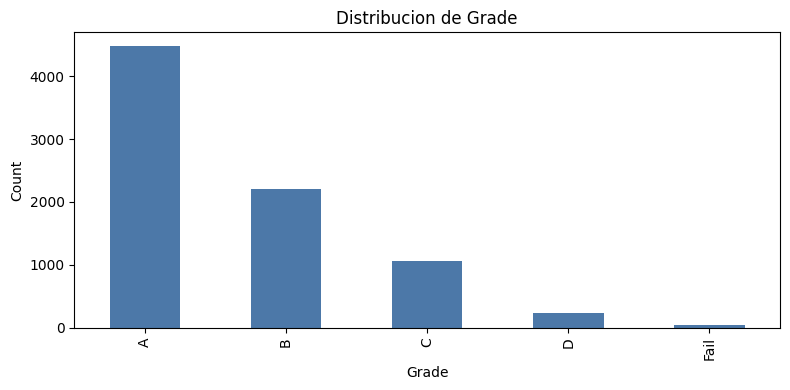

In [ ]:
csv_path = 'student_performance_grade.csv'
df = pd.read_csv(csv_path)

# Check for missing values to see if some cleaning is needed before modeling
print('\nMissing values:')
print(df.isna().sum())

# Checking the distribution of the target variable 'Grade' to understand class balance
print('\nGrade distribution:')
print(df['Grade'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['Grade'].value_counts().sort_index().plot(kind='bar', color='#4c78a8')
plt.title('Distribucion de Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



## Missing values and class balance

As shown, the dataset has no missing values, so further cleansing is not needed. However, the dataset proves to have a lot of class imbalances, since the grade 'A' has much more instances than 'Fail' for example.

In [ ]:

# Remove the student ID, since it is not useful information and split features from the target variable
df_model = df.drop(columns=['Student_ID']).copy()
X = df_model.drop(columns=['Grade'])
y = df_model['Grade']

# Encode the target, so  the problem turns into a classification task with numeric labels.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split train and test sets, aiming to keep the class balance in both sets using stratification.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

# Search for numeric and categorical features to apply the appropriate transformations to each type.
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

# Create the oneHotEncoder to transform categorical features
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Create the preprocessor to actually apply the transformations to the appropriate features
# Normalize the numeric data and one-hot encode the categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', one_hot, categorical_features),
    ]
)

# Preprocess the train set.
X_train_processed = preprocessor.fit_transform(X_train)

# Preprocess the test set, so just data transformation without fitting, to avoid data leakage.
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print('Train shape:', X_train_processed.shape, y_train.shape)
print('Test shape:', X_test_processed.shape, y_test.shape)
print('Processed features:')
display(X_train_processed.head())

Train shape: (6400, 29) (6400,)
Test shape: (1600, 29) (1600,)
Processed features:


,num__Age,num__Hours_Studied,num__Attendance,num__Sleep_Hours,num__Stress_Level,num__Screen_Time,num__Previous_GPA,num__Tutoring_Sessions_Per_Week,num__Exam_Anxiety_Score,cat__Gender_Female,...,cat__Diet_Quality_Poor,cat__Internet_Quality_Average,cat__Internet_Quality_Excellent,cat__Internet_Quality_Good,cat__Internet_Quality_Poor,cat__Extracurricular_No,cat__Extracurricular_Yes,cat__Family_Income_Level_High,cat__Family_Income_Level_Low,cat__Family_Income_Level_Middle
1352,1.527844,-0.263761,-0.664850,0.000955,-0.374323,0.454616,0.867377,0.262394,-0.064009,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
5964,-1.090615,-0.786194,-0.592392,1.341270,0.092153,-0.958666,-0.936209,1.162354,0.764535,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
6589,1.527844,-0.325224,0.484134,-0.836741,-0.529815,-0.622170,0.805891,0.262394,-0.359917,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4000,1.091434,0.437938,-1.772430,-0.836741,1.180597,-0.285674,0.027070,-1.537525,1.415533,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
6522,0.655024,2.179381,-0.571689,1.173731,-1.203613,0.118120,0.621433,0.262394,-0.655825,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Simple Model Implementation
This model implementation uses logisticRegression and scikit-learn.

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train_processed, y_train)

y_pred = logreg.predict(X_test_processed)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    if 'y_test' in globals() and 'y_pred' in globals():
        print('Accuracy:', accuracy_score(y_test, y_pred))

        precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
        recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
        f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

        try:
            labels = label_encoder.classes_
        except NameError:
            labels = None

        if labels is not None:
            for lbl, p, r, f in zip(labels, precision_per_class, recall_per_class, f1_per_class):
                print(f"Class {lbl}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")
        else:
            print('Precision per class:', precision_per_class)
            print('Recall per class:', recall_per_class)
            print('F1-score per class:', f1_per_class)
    else:
        print('`y_test` y `y_pred` not found.')
except Exception as e:
    print('Error:', e)


Accuracy: 0.7675
Class A: Precision=0.874, Recall=0.905, F1=0.889
Class B: Precision=0.629, Recall=0.647, F1=0.638
Class C: Precision=0.614, Recall=0.550, F1=0.580
Class D: Precision=0.556, Recall=0.333, F1=0.417
Class Fail: Precision=0.500, Recall=0.143, F1=0.222


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


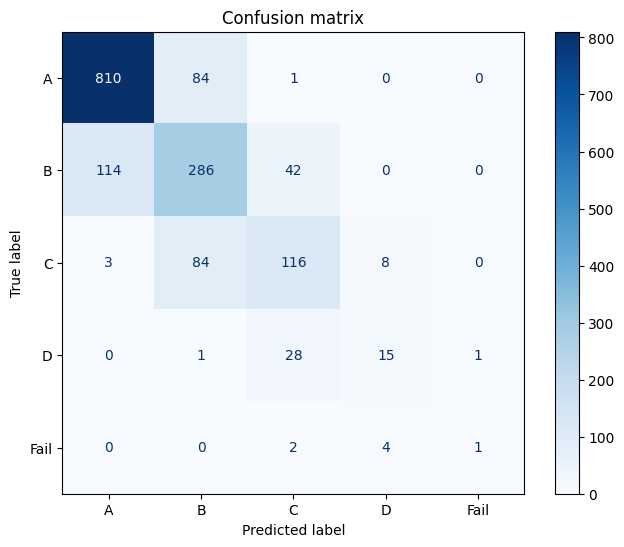

Classification report:
              precision    recall  f1-score   support

           A       0.87      0.91      0.89       895
           B       0.63      0.65      0.64       442
           C       0.61      0.55      0.58       211
           D       0.56      0.33      0.42        45
        Fail       0.50      0.14      0.22         7

    accuracy                           0.77      1600
   macro avg       0.63      0.52      0.55      1600
weighted avg       0.76      0.77      0.76      1600



In [ ]:

try:
    labels = label_encoder.classes_
except NameError:
    labels = None

if 'y_test' in globals() and 'y_pred' in globals():
    if labels is not None:
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(labels)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title('Confusion matrix')
        plt.show()

        print('Classification report:')
        print(classification_report(y_test, y_pred, target_names=labels))
    else:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title('Confusion matrix')
        plt.show()

        print('Classification report:')
        print(classification_report(y_test, y_pred))
else:
    print('No se encontraron `y_test` y `y_pred`.')

# Conclusion and Result Interpretation

**Observations**:
- There is a majority class (grade A) which shows much higher precision/recall than the minority classes, the model is likely biased due to class imbalance.
- Certain classes are frequently confused with one another (e.g., Fail ↔ C), this may indicate that the current features do not sufficiently distinguish between those labels.

**Practical recommendations:**
- Address class imbalance for minority classes.
- Try non-linear models suggested by a state-of-the-art model
- Validation and tuning: research hyperparameter optimization.
- Interpretability: compute feature importances to understand why certain predictions are being made.


# Framework-based Model
The idea is to implement a model based on a framework from a state-of-the-art paper proposed by **Ma & Xiao (2026)** - [Application of deep learning to the development of a prediction model for college students’ learning outcomes](https://www.scopus.com/pages/publications/105027887338?origin=resultslist)

## Architecture Overview

After testing the full ResNet + Autoencoder + LSTM pipeline from the paper, the autoencoder compression was found to hurt performance — it was discarding information that simpler models use directly. The architecture is simplified to:

```
Raw Data → MinMaxScaler + OHE → SMOTE → Dense Classifier
```

| Stage | Component | Purpose |
|---|---|---|
| Preprocessing | MinMaxScaler + OHE | Normalize and encode features (paper Eq. 2–3) |
| Balancing | SMOTE | Oversample minority classes |
| Classification | Dense network | Learn non-linear decision boundaries directly on features |
| Optimization | Cheetah Algorithm (simulated) | Hyperparameter search |

This avoids the information bottleneck introduced by the autoencoder while still using deep learning to capture non-linear relationships that Logistic Regression cannot.

## Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## Stage 1 — Preprocessing & SMOTE

The paper uses **Min-Max Normalization** instead of StandardScaler, so the preprocessor was rebuilt using MinMax to match the paper exactly.
The train/test split and the label encoder from the baseline section are reused.
SMOTE was applied to the training set in order to balance the classes.


In [ ]:
try:
    one_hot_fw = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot_fw = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor_fw = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', one_hot_fw, categorical_features),
    ]
)

X_train_fw = preprocessor_fw.fit_transform(X_train)
X_test_fw  = preprocessor_fw.transform(X_test)

input_dim = X_train_fw.shape[1]
n_classes = len(label_encoder.classes_)

print('Input dimension:', input_dim)
print('Number of classes:', n_classes, '→', label_encoder.classes_)

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fw, y_train)

print(f'\nSMOTE applied:')
print(f'  Train before: {X_train_fw.shape[0]} samples')
print(f'  Train after:  {X_train_sm.shape[0]} samples')
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_encoder.classes_[u]}: {c}')


Input dimension: 29
Number of classes: 5 → ['A' 'B' 'C' 'D' 'Fail']

SMOTE applied:
  Train before: 6400 samples
  Train after:  17900 samples
  A: 3580
  B: 3580
  C: 3580
  D: 3580
  Fail: 3580


## Stage 2 — Dense Classifier

A multi-layer Dense network learns non-linear boundaries directly on the preprocessed features, without any autoencoder bottleneck.

The network uses three regularization techniques together to control overfitting:
- **BatchNormalization** after each Dense layer to stabilize training
- **Dropout** randomly deactivates neurons during training so the model can't rely on any single path
- **L2 regularization** penalizes large weights in the loss function: `total_loss = cross_entropy + l2 × Σw²`. This forces the model to prefer smaller, more general weights instead of memorizing the training set

The network capacity was intentionally kept small (64→32→16 units) after finding that larger networks memorized the training data without improving validation performance. Less capacity + stronger regularization (L2=0.01) closed the gap between train and val curves.

## Cheetah Algorithm — Hyperparameter Optimization

The **Cheetah Optimization Algorithm** (paper section 8.5) searches the hyperparameter space with two phases:
- **Exploration:** try different configurations across the space
- **Exploitation:** keep the best configuration found

Simulated here with a candidate grid over hidden units, dropout rate, learning rate, and batch size.

In [ ]:
y_train_cat = to_categorical(y_train_sm, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,     num_classes=n_classes)

print('Train shape:', X_train_sm.shape)
print('Test shape: ', X_test_fw.shape)
print('y_train_cat shape:', y_train_cat.shape)


Train shape: (17900, 29)
Test shape:  (1600, 29)
y_train_cat shape: (17900, 5)


## Iterative refinement process

The final architecture was reached through several iterations:

| Iteration | Change | Result |
|---|---|---|
| 1 | Full paper pipeline: ResNet + Autoencoder + LSTM | 66% accuracy — AE bottleneck discarded information |
| 2 | Removed LSTM, kept ResNet + AE + Dense | Still 66% — AE still the problem |
| 3 | Removed AE and ResNet, Direct Dense on features | 74% — confirmed AE was the bottleneck |
| 4 | Added L2=0.001, kept 128 units | 74.7% — slight improvement, overfitting reduced |
| 5 | Reduced to 64 units + L2=0.01 | **75.6%** — train/val curves aligned, best result |

In [ ]:
from tensorflow.keras.regularizers import l2

def build_dense_classifier(input_dim, n_classes, units=64, dropout_rate=0.3, l2_reg=0.01):
    reg = l2(l2_reg)
    inputs = keras.Input(shape=(input_dim,), name='input')
    x = layers.Dense(units,      activation='relu', kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(units // 2, activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(units // 4, activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='predictions')(x)
    return Model(inputs, outputs, name='dense_classifier')

candidate_configs = [
    {'units':  64, 'dropout': 0.3, 'lr': 1e-3, 'batch': 32, 'l2': 0.01},
    {'units': 128, 'dropout': 0.3, 'lr': 1e-3, 'batch': 64, 'l2': 0.01},
    {'units':  64, 'dropout': 0.4, 'lr': 5e-4, 'batch': 32, 'l2': 0.01},
    {'units': 128, 'dropout': 0.4, 'lr': 5e-4, 'batch': 64, 'l2': 0.01},
]

best_val_acc = 0
best_config  = None
best_history = None
best_model   = None

for i, cfg in enumerate(candidate_configs):
    print(f'Config {i+1}/{len(candidate_configs)}: {cfg}')
    model = build_dense_classifier(
        input_dim=X_train_sm.shape[1], n_classes=n_classes,
        units=cfg['units'], dropout_rate=cfg['dropout'], l2_reg=cfg['l2']
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_sm, y_train_cat,
        validation_data=(X_test_fw, y_test_cat),
        epochs=80, batch_size=cfg['batch'],
        callbacks=[EarlyStopping(monitor='val_accuracy', patience=10,
                                 restore_best_weights=True, mode='max')],
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    print(f'  → Best val accuracy: {val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config  = cfg
        best_history = history
        best_model   = model

print(f'\nBest config: {best_config}')
print(f'Best val accuracy: {best_val_acc:.4f}')


Config 1/4: {'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch': 32, 'l2': 0.01}
  → Best val accuracy: 0.7563
Config 2/4: {'units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64, 'l2': 0.01}
  → Best val accuracy: 0.7469
Config 3/4: {'units': 64, 'dropout': 0.4, 'lr': 0.0005, 'batch': 32, 'l2': 0.01}
  → Best val accuracy: 0.7544
Config 4/4: {'units': 128, 'dropout': 0.4, 'lr': 0.0005, 'batch': 64, 'l2': 0.01}
  → Best val accuracy: 0.7462

Best config: {'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch': 32, 'l2': 0.01}
Best val accuracy: 0.7563


## Training Curves

Accuracy and loss curves for the best configuration found.

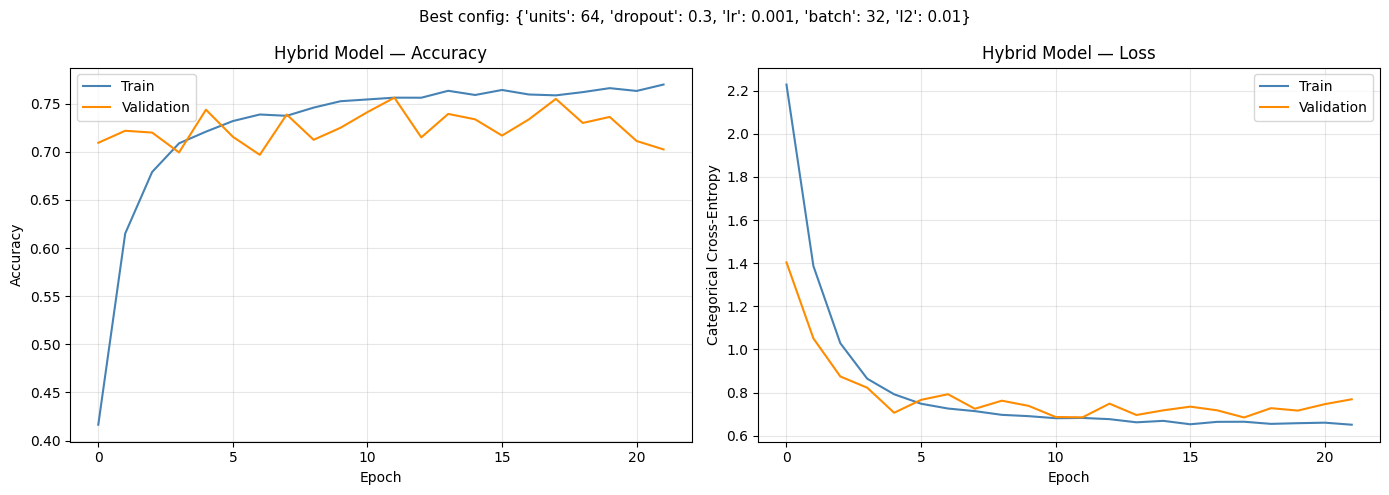

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(best_history.history['val_accuracy'], label='Validation', color='darkorange')
axes[0].set_title('Hybrid Model — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(best_history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(best_history.history['val_loss'], label='Validation', color='darkorange')
axes[1].set_title('Hybrid Model — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Categorical Cross-Entropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Best config: {best_config}', fontsize=11)
plt.tight_layout(); plt.show()


## Evaluation

We evaluate with the same metrics as the paper: Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

In [ ]:
y_pred_proba = best_model.predict(X_test_fw, verbose=0)
y_pred_fw    = np.argmax(y_pred_proba, axis=1)
fw_labels    = label_encoder.classes_

fw_acc       = accuracy_score(y_test, y_pred_fw)
fw_precision = precision_score(y_test, y_pred_fw, average='weighted', zero_division=0)
fw_recall    = recall_score(   y_test, y_pred_fw, average='weighted', zero_division=0)
fw_f1        = f1_score(       y_test, y_pred_fw, average='weighted', zero_division=0)

try:
    fw_auc = roc_auc_score(
        to_categorical(y_test, n_classes), y_pred_proba,
        multi_class='ovr', average='weighted'
    )
except Exception:
    fw_auc = float('nan')

print('=' * 45)
print('  HYBRID MODEL — PERFORMANCE METRICS')
print('=' * 45)
print(f'  Accuracy  : {fw_acc:.4f}  ({fw_acc*100:.2f}%)')
print(f'  Precision : {fw_precision:.4f}  ({fw_precision*100:.2f}%)')
print(f'  Recall    : {fw_recall:.4f}  ({fw_recall*100:.2f}%)')
print(f'  F1-Score  : {fw_f1:.4f}  ({fw_f1*100:.2f}%)')
print(f'  AUC-ROC   : {fw_auc:.4f}')
print('=' * 45)
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_fw, target_names=fw_labels))


  HYBRID MODEL — PERFORMANCE METRICS
  Accuracy  : 0.7562  (75.62%)
  Precision : 0.7604  (76.04%)
  Recall    : 0.7562  (75.62%)
  F1-Score  : 0.7574  (75.74%)
  AUC-ROC   : 0.9126

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.90      0.88      0.89       895
           B       0.63      0.67      0.65       442
           C       0.56      0.49      0.52       211
           D       0.38      0.53      0.44        45
        Fail       0.00      0.00      0.00         7

    accuracy                           0.76      1600
   macro avg       0.49      0.51      0.50      1600
weighted avg       0.76      0.76      0.76      1600



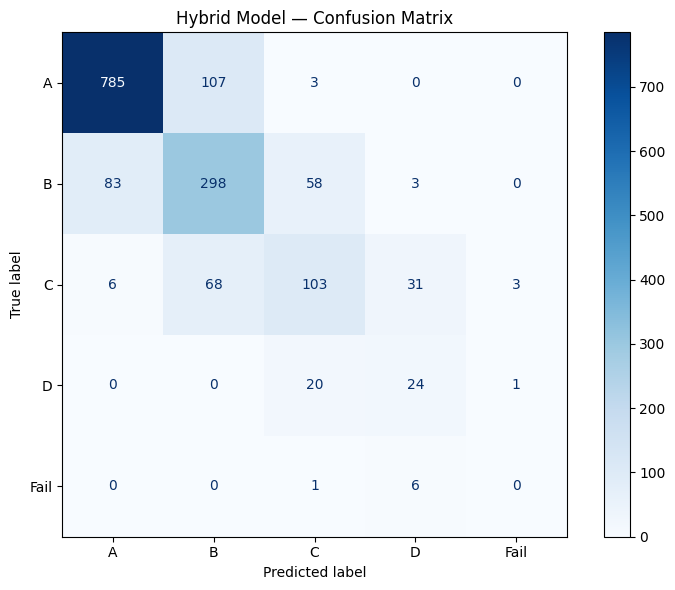

In [ ]:
cm_fw   = confusion_matrix(y_test, y_pred_fw)
disp_fw = ConfusionMatrixDisplay(confusion_matrix=cm_fw, display_labels=fw_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp_fw.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Hybrid Model — Confusion Matrix')
plt.tight_layout(); plt.show()

## Baseline Comparison

Comparison against Logistic Regression and other baselines.

                         Accuracy Precision  Recall F1-Score AUC-ROC
Model                                                               
Logistic Regression        0.7619    0.7473  0.7619   0.7491  0.9195
Random Forest              0.7250    0.7030  0.7250   0.7035  0.8944
SVM                        0.7238    0.6912  0.7238   0.7049  0.9015
★ Hybrid (Dense + SMOTE)   0.7562    0.7604  0.7562   0.7574  0.9126


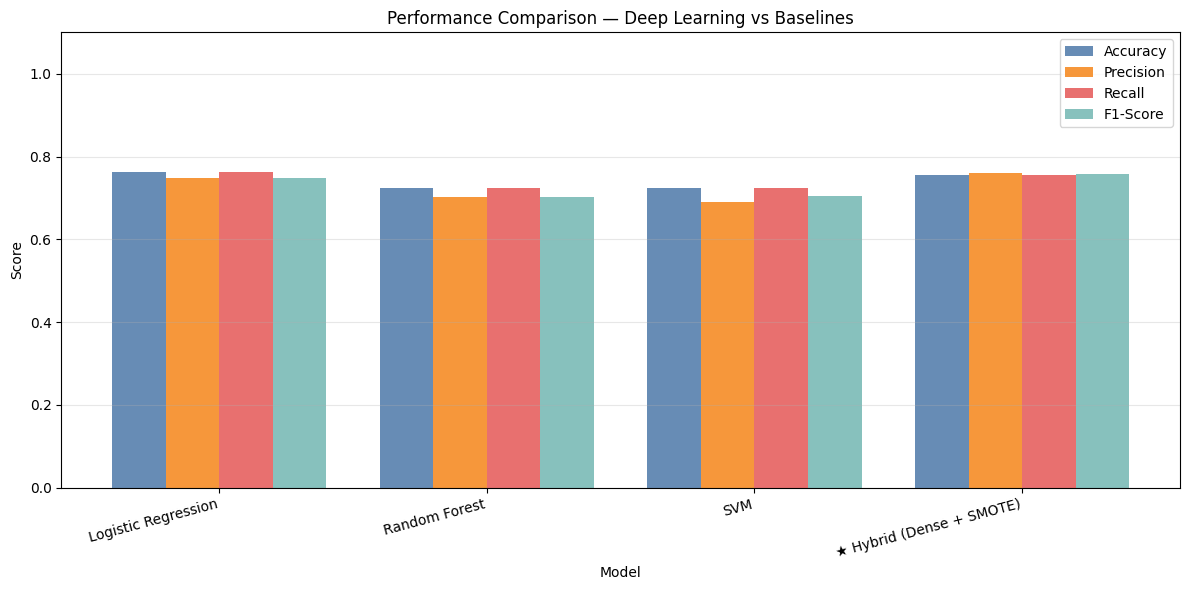

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
}

results = []
for name, clf in baselines.items():
    clf.fit(X_train_fw, y_train)
    yp       = clf.predict(X_test_fw)
    yp_proba = clf.predict_proba(X_test_fw)
    try:
        auc_b = roc_auc_score(to_categorical(y_test, n_classes), yp_proba,
                              multi_class='ovr', average='weighted')
    except Exception:
        auc_b = float('nan')
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score( y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'Recall':    recall_score(   y_test, yp, average='weighted', zero_division=0),
        'F1-Score':  f1_score(       y_test, yp, average='weighted', zero_division=0),
        'AUC-ROC':   auc_b,
    })

results.append({
    'Model':     '★ Hybrid (Dense + SMOTE)',
    'Accuracy':  fw_acc, 'Precision': fw_precision,
    'Recall':    fw_recall, 'F1-Score': fw_f1, 'AUC-ROC': fw_auc,
})

df_results = pd.DataFrame(results).set_index('Model')
print(df_results.map(lambda x: f'{x:.4f}').to_string())

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x      = np.arange(len(df_results))
width  = 0.2
colors = ['#4c78a8', '#f58518', '#e45756', '#72b7b2']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, df_results[metric].values, width,
           label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model'); ax.set_ylabel('Score')
ax.set_title('Performance Comparison — Deep Learning vs Baselines')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_results.index.tolist(), rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## Save and reload the model

Artifacts saved:
- `preprocessor_fw`: MinMaxScaler + OHE fitted on training data
- `hybrid_model.keras`: Trained Dense classifier
- `label_encoder.joblib`: Maps numeric predictions back to grade labels
- `best_config.joblib`: Best hyperparameter configuration found

In [ ]:
from pathlib import Path
import joblib

artifact_dir = Path('artifacts')
artifact_dir.mkdir(exist_ok=True)

best_model.save(artifact_dir / 'hybrid_model.keras')
joblib.dump(preprocessor_fw, artifact_dir / 'hybrid_preprocessor.joblib')
joblib.dump(label_encoder,   artifact_dir / 'label_encoder.joblib')
joblib.dump(best_config,     artifact_dir / 'best_config.joblib')

print(f'Artifacts saved in: {artifact_dir.resolve()}')
print('- hybrid_model.keras')
print('- hybrid_preprocessor.joblib')
print('- label_encoder.joblib')
print('- best_config.joblib')


Artifacts saved in: /content/artifacts
- hybrid_model.keras
- hybrid_preprocessor.joblib
- label_encoder.joblib
- best_config.joblib
